In [1]:
%matplotlib inline
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

import torch
import torch.nn as nn
import gymnasium as gym
from minatar.gym import register_envs
from plotting import plot_compare_smoothed_rewards
from collections import deque


In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

## Q3 Part 1 - Visualization of MinAtar Breakout-v1

In [3]:
# Visualization functions
def visualize_state_per_channel(state):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i, ax in enumerate(axes):
        ax.set_title(f'Channel {i}')
        ax.imshow(state[:, :, i], cmap='gray')
    plt.tight_layout()
    plt.show()

def _draw_state(state, ax, title=None):
    """Draw a combined state representation onto the given Axes."""
    n_channels = state.shape[-1]
    cmap_list = [(0, 0, 0)] + sns.color_palette("cubehelix", n_channels)
    cmap = colors.ListedColormap(cmap_list)
    norm = colors.BoundaryNorm(range(n_channels + 2), n_channels + 1)
    numerical_state = np.amax(state * np.arange(1, n_channels + 1), axis=2) + 0.5
    ax.imshow(numerical_state, cmap=cmap, norm=norm, interpolation='none')
    ax.set_title(title or '')
    ax.axis('off')

def visualize_state(state, title=None):
    """Display a single state as a standalone figure."""
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    _draw_state(state, ax, title)
    plt.tight_layout()
    plt.show()

def visualize_states_grid(states, titles=None, ncols=None):
    """Display multiple states in a single figure, laid out row by row."""
    n = len(states)
    if n == 0:
        return
    if titles is None:
        titles = [None] * n
    if ncols is None:
        ncols = n
    nrows = -(-n // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()
    for ax, state, title in zip(axes_flat, states, titles):
        _draw_state(state, ax, title)
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.tight_layout()
    plt.show()

In [4]:
# Initalize environment
if 'MinAtar/Breakout-v1' not in gym.registry:
    register_envs()
    print("Registered MinAtar environments.")
env = gym.make("MinAtar/Breakout-v1")

# Environment specifications
print(f"Environment: {env}")
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")

Registered MinAtar environments.
Environment: <OrderEnforcing<PassiveEnvChecker<BaseEnv<MinAtar/Breakout-v1>>>>
Observation Space: Box(False, True, (10, 10, 4), bool)
Action Space: Discrete(3)


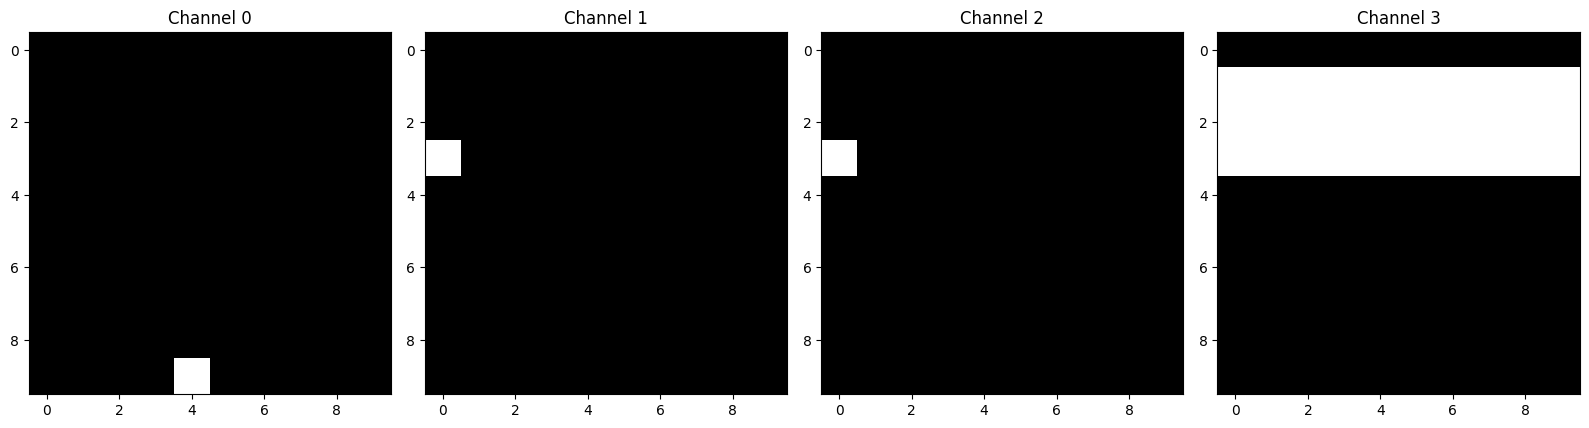

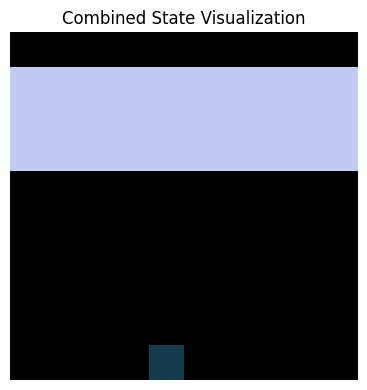

In [5]:
# Reset environment and visualize initial state
state, info = env.reset()
visualize_state_per_channel(state)
visualize_states_grid([state], titles=["Combined State Visualization"])

Step: 1, Action: 0, Reward: 0, Done: False, Truncated: False
Step: 2, Action: 0, Reward: 0, Done: False, Truncated: False
Step: 3, Action: 0, Reward: 0, Done: False, Truncated: False
Step: 4, Action: 1, Reward: 0, Done: False, Truncated: False
Step: 5, Action: 0, Reward: 0, Done: False, Truncated: False


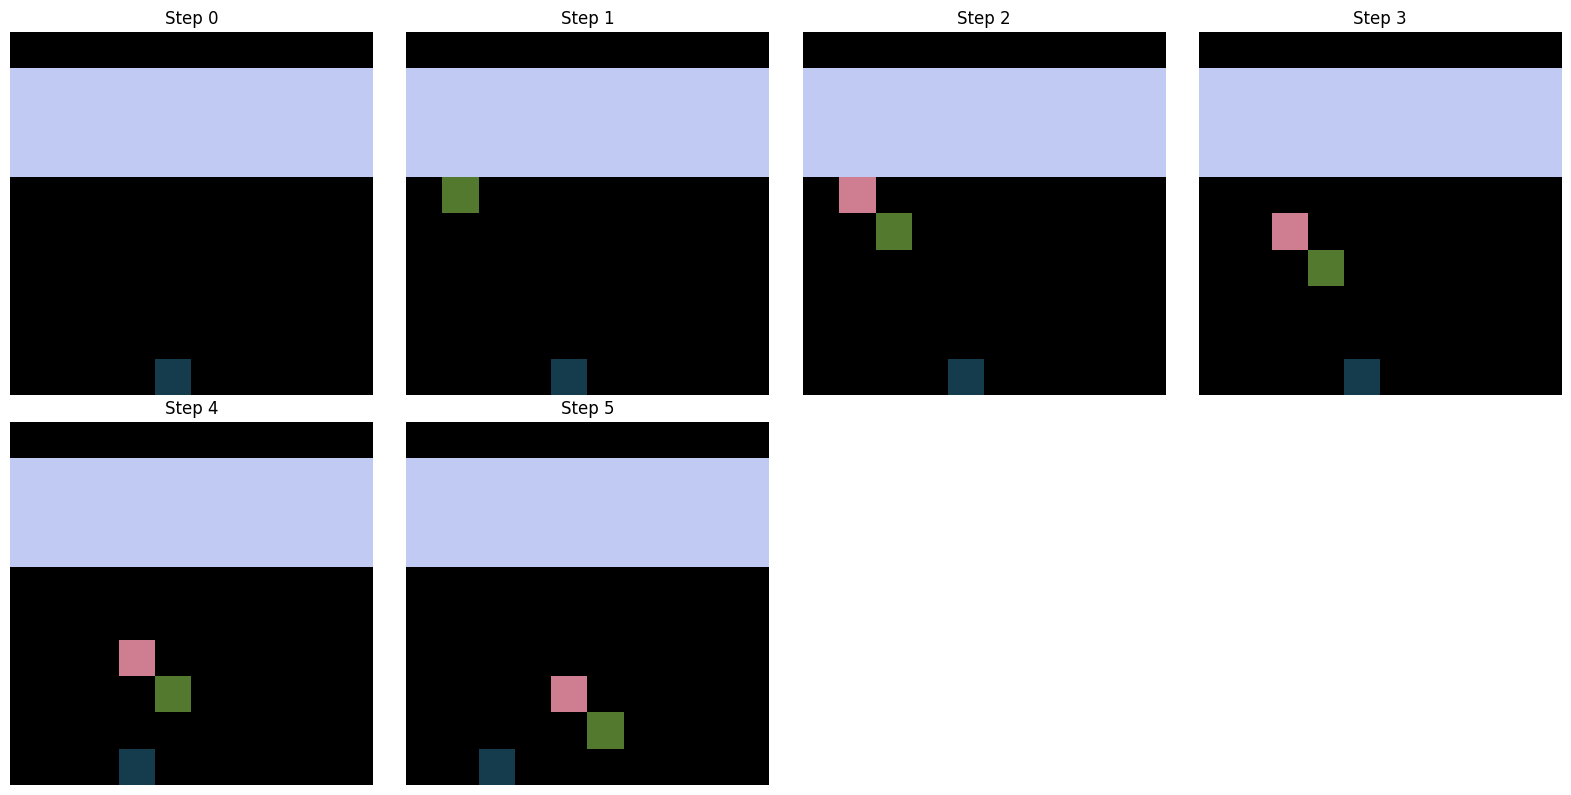

In [6]:
# Take random actions and visualize the resulting states
step_states, step_titles = [], []

state, info = env.reset()
step_states.append(state)
step_titles.append(f"Step {0}")

for i in range(5):
    action = env.action_space.sample()
    next_state, reward, done, truncated, info = env.step(action)
    print(f"Step: {i + 1}, Action: {action}, Reward: {reward}, Done: {done}, Truncated: {truncated}")
    step_states.append(next_state)
    step_titles.append(f"Step {i + 1}")

visualize_states_grid(step_states, titles=step_titles, ncols=4)

Legend
- Dark blue = Paddle
- Green = Ball
- Pink = Trailing position of the ball
- Purple = Brick

Here, we take a small number of random actions. The action space is composed of three actions: stay put (0), go left (1), or go right (2). The actions control the paddle. The ball is spawned either from the left or the right side of the screen and moves diagonally. If the ball is falling and is not caught by the paddle, the episode ends.


## Q3 Part b Control with Experience Replay - DQN Variants


In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)
        self.relu = nn.ReLU()

        # Initialize weights uniformly in the range [-0.001, 0.001]
        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.uniform_(layer.weight, a=-0.001, b=0.001)
            nn.init.zeros_(layer.bias)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

### Sequential Updates (no replay buffer)

In [8]:
GAMMA = 0.99
WARMUP_STEPS = 1000
BATCH_SIZE = 64

In [9]:
def run_sequential_dqn(
    learning_rates = [1e-4, 5e-4, 1e-3],
    num_episodes = 3000,
    num_runs = 5,
    eps = 0.05,
    warmup_steps = 1000,
    device = "cpu"
):
    if device not in ["cpu", "cuda", "mps"]:
        raise ValueError(f"Invalid device '{device}'. Supported devices are 'cpu', 'cuda', and 'mps'.")
    elif device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
        print("cuda not available, falling back to cpu.")
    else:
        print(f"Using device: {device}")

    loss_fn = nn.MSELoss()
    return_results = {} # Store return results for each learning rate
    loss_results = {}   # Store loss results for each learning rate
    models = {}         # Store trained models (state_dicts) for each learning rate

    # Training loop for different learning rates
    for lr in learning_rates:
        print(f"Running DQN with learning rate: {lr}")
        lr_returns = [] 
        lr_losses = []
        lr_models = []

        for run in range(num_runs):
            # Ensure different seed for each run
            env.reset(seed = RANDOM_SEED + run)

            # Initialize Q-network and Adam optimizer
            Q = MLP(input_dim=400, output_dim=3).to(device)
            optimizer = torch.optim.Adam(Q.parameters(), lr=lr)

            # Initialize the target network and copy weights from Q-network
            target_Q = MLP(input_dim=400, output_dim=3).to(device)
            target_Q.load_state_dict(Q.state_dict())
            reset_target_steps = 1000  # Update target network every 1000 steps
            step_count = 0
            
            run_returns = []
            run_losses = []

            # Start training the agent
            for episode in range(num_episodes):
                state, info = env.reset()
                done = False
                truncated = False
                episode_return = 0
                episode_loss_sum = 0
                episode_steps = 0

                while not (done or truncated):
                    # Flatten the current state and convert to PyTorch tensor
                    state_tensor = torch.tensor(state.flatten(), dtype=torch.float32).unsqueeze(0).to(device) # [1, 400]

                    # Select action according to epsilon-greedy
                    if step_count < warmup_steps:
                         action = env.action_space.sample()
                    elif random.random() < eps:
                        action = env.action_space.sample()
                    else:
                        with torch.no_grad():
                            q_values = Q(state_tensor)
                            action = q_values.argmax().item()
                    
                    # Observe next state and reward
                    next_state, reward, done, truncated, info = env.step(action)
                    
                    episode_return += GAMMA ** episode_steps * reward

                    step_count += 1
                    episode_steps += 1

                    # Only train after warmup steps
                    loss_val = 0
                    if step_count > warmup_steps:
                        # Compute prediction
                        current_q_values = Q(state_tensor)
                        prediction = current_q_values[0, action]

                        # Compute Target
                        with torch.no_grad():
                            next_state_tensor = torch.tensor(next_state.flatten(), dtype=torch.float32).unsqueeze(0).to(device) # [1, 400]
                            target_q_values = target_Q(next_state_tensor)
                            target = reward + GAMMA * target_q_values.max() * (1 - int(done))

                        # Compute loss
                        loss = loss_fn(prediction, target)
                        loss_val = loss.item()

                        # Backpropagate gradients and update weights in Q-network
                        optimizer.zero_grad() 
                        loss.backward()
                        optimizer.step()

                        # Update target network periodically
                        if step_count % reset_target_steps == 0:
                            target_Q.load_state_dict(Q.state_dict())

                    # Track metrics and transition to next state
                    episode_loss_sum += loss_val
                    state = next_state
                
                run_returns.append(episode_return)
                run_losses.append(episode_loss_sum / episode_steps)
            
            lr_returns.append(run_returns)
            lr_losses.append(run_losses)
            # Move state dict to CPU to save memory and ensure device-agnostic saving
            lr_models.append({k: v.cpu() for k, v in Q.state_dict().items()})
        
        return_results[lr] = lr_returns
        loss_results[lr] = lr_losses
        models[lr] = lr_models

    return return_results, loss_results, models

In [10]:
# Test run with small parameters
_, _, _ = run_sequential_dqn(learning_rates=[1e-4], num_episodes=10, num_runs=1)

Using device: cpu
Running DQN with learning rate: 0.0001


Using device: cpu
Running DQN with learning rate: 0.0001
Running DQN with learning rate: 0.0005
Running DQN with learning rate: 0.001


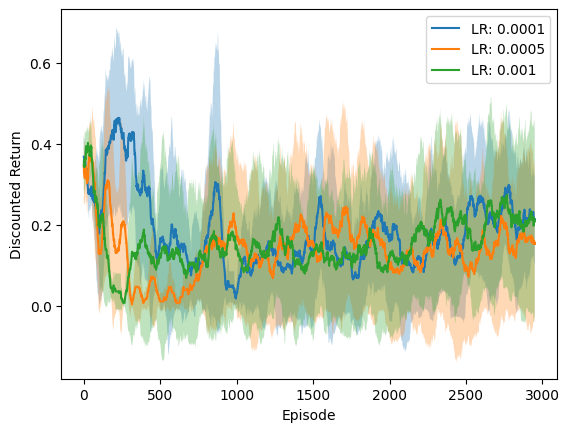

In [11]:
# Run the experiment
returns, losses, seq_models = run_sequential_dqn(
    learning_rates=[1e-4, 5e-4, 1e-3], 
    num_episodes=3000,
    num_runs=5,
    warmup_steps=1000,
    device = "cpu"
)

# Convert into the format expected by plotting.py
# Format: list of list of lists (Methods -> Seeds -> Episodes)
all_methods_data = []
all_labels = []

for lr, seeds_data in returns.items():
    all_methods_data.append(seeds_data)
    all_labels.append(f"LR: {lr}")

# Plot using the provided utility
plot_compare_smoothed_rewards(
    train_rewards_list=all_methods_data,
    labels=all_labels,
    window=50,
    xlabel="Episode",
    ylabel="Discounted Return"
)

## Uniform Sampling

In [13]:
class ReplayBuffer:
    def __init__(self, capacity=50000):
        # deque automatically discards the oldest items when maxlen is reached
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*transitions)
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards),
            np.array(next_states),
            np.array(dones)
        )
    
    def __len__(self):
        return len(self.buffer)

In [14]:
def run_replay_uniform_sampling_dqn(
    learning_rates = [1e-4, 5e-4, 1e-3],
    num_episodes = 3000,
    num_runs = 5,
    eps = 0.05,
    warmup_steps = 1000,
    device = "cpu"
):
    if device not in ["cpu", "cuda", "mps"]:
        raise ValueError(f"Invalid device '{device}'. Supported devices are 'cpu', 'cuda', and 'mps'.")
    elif device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
        print("cuda not available, falling back to cpu.")
    else:
        print(f"Using device: {device}")

    loss_fn = nn.MSELoss()
    return_results = {} # Store return results for each learning rate
    loss_results = {}   # Store loss results for each learning rate
    models = {}         # Store trained models (state_dicts) for each learning rate

    # Training loop for different learning rates
    for lr in learning_rates:
        print(f"Running Experience Replay with Uniform Sampling DQN with learning rate: {lr}")
        lr_returns = []
        lr_losses = []
        lr_models = []

        for run in range(num_runs):
            # Ensure different seed for each run
            env.reset(seed = RANDOM_SEED + run)

            # Initialize replay buffer with capacity of 50000 transitions
            replay_buffer = ReplayBuffer(capacity=50000)

            # Initialize Q-network and Adam optimizer
            Q = MLP(input_dim=400, output_dim=3).to(device)
            optimizer = torch.optim.Adam(Q.parameters(), lr=lr)

            # Initialize the target network and copy weights from Q-network
            target_Q = MLP(input_dim=400, output_dim=3).to(device)
            target_Q.load_state_dict(Q.state_dict())
            reset_target_steps = 1000  # Update target network every 1000 steps
            step_count = 0
            
            run_returns = [] 
            run_losses = []

            # Start training the agent
            for episode in range(num_episodes):
                state, info = env.reset()
                done = False
                truncated = False
                episode_return = 0
                episode_loss_sum = 0
                episode_steps = 0

                while not (done or truncated):
                    # Flatten the current state and convert to PyTorch tensor
                    state_tensor = torch.tensor(state.flatten(), dtype=torch.float32).unsqueeze(0).to(device) # [1, 400]

                    # Select action according to epsilon-greedy
                    if step_count < warmup_steps:
                         action = env.action_space.sample()
                    elif random.random() < eps:
                        action = env.action_space.sample()
                    else:
                        with torch.no_grad():
                            q_values = Q(state_tensor)
                            action = q_values.argmax().item()
                    
                    # Observe next state and reward
                    next_state, reward, done, truncated, info = env.step(action)

                    # Add discounted reward for this step to episode return
                    episode_return += GAMMA ** episode_steps * reward

                    # Store transition in replay buffer
                    replay_buffer.push(state.flatten(), action, reward, next_state.flatten(), done)
                    
                    # Only train after warmup steps
                    loss_val = 0
                    if step_count > warmup_steps and len(replay_buffer) >= BATCH_SIZE:
                        # Sample a batch from the replay buffer
                        states_batch, actions_batch, rewards_batch, next_states_batch, dones_batch = replay_buffer.sample(BATCH_SIZE)
                        
                        states_tensor = torch.tensor(states_batch, dtype=torch.float32).to(device)
                        actions_tensor = torch.tensor(actions_batch, dtype=torch.int64).to(device)
                        rewards_tensor = torch.tensor(rewards_batch, dtype=torch.float32).to(device)
                        next_states_tensor = torch.tensor(next_states_batch, dtype=torch.float32).to(device)
                        dones_tensor = torch.tensor(dones_batch, dtype=torch.float32).to(device)

                        # Compute prediction
                        current_q_values = Q(states_tensor)
                        predictions = current_q_values.gather(1, actions_tensor.unsqueeze(1)).squeeze(1)

                        # Compute Target
                        with torch.no_grad():
                            target_q_values = target_Q(next_states_tensor)
                            targets = rewards_tensor + GAMMA * target_q_values.max(1)[0] * (1 - dones_tensor)

                        # Compute loss
                        loss = loss_fn(predictions, targets)
                        loss_val = loss.item()

                        # Backpropagate gradients and update weights in Q-network
                        optimizer.zero_grad() 
                        loss.backward()
                        optimizer.step()

                        # Update target network periodically
                        if step_count % reset_target_steps == 0:
                            target_Q.load_state_dict(Q.state_dict())

                    # Track metrics and transition to next state
                    episode_loss_sum += loss_val
                    step_count += 1
                    episode_steps += 1
                    state = next_state
                
                run_returns.append(episode_return)
                run_losses.append(episode_loss_sum / episode_steps)
            
            lr_returns.append(run_returns)
            lr_losses.append(run_losses)
            # Move state dict to CPU to save memory and ensure device-agnostic saving
            lr_models.append({k: v.cpu() for k, v in Q.state_dict().items()})
        
        return_results[lr] = lr_returns
        loss_results[lr] = lr_losses
        models[lr] = lr_models

    return return_results, loss_results, models

In [15]:
returns, losses, replay_models = run_replay_uniform_sampling_dqn(
    learning_rates = [1e-4, 5e-4, 1e-3],
    num_episodes = 3000,
    num_runs = 5,
    eps = 0.05,
    warmup_steps = 1000,
    device = "cuda"
)

Using device: cuda
Running Experience Replay with Uniform Sampling DQN with learning rate: 0.0001
Running Experience Replay with Uniform Sampling DQN with learning rate: 0.0005
Running Experience Replay with Uniform Sampling DQN with learning rate: 0.001


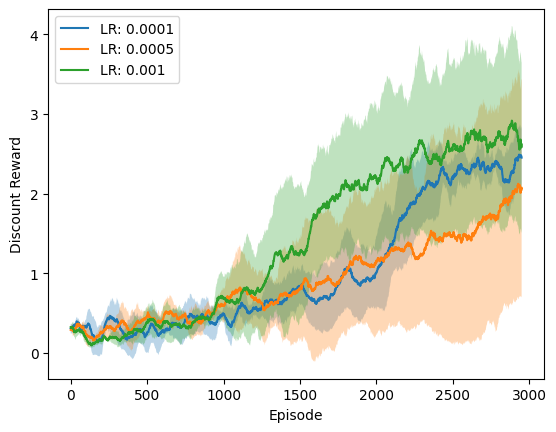

In [16]:
# Convert your results into the format expected by plotting.py
# Format: list of list of lists (Methods -> Seeds -> Episodes)
all_methods_data = []
all_labels = []

for lr, seeds_data in returns.items():
    all_methods_data.append(seeds_data)
    all_labels.append(f"LR: {lr}")

# Plot using the provided utility
plot_compare_smoothed_rewards(
    train_rewards_list=all_methods_data,
    labels=all_labels,
    window=50,
    xlabel="Episode",
    ylabel="Discount Return"
)

## Prioritized Sampling

In [19]:
GAMMA = 0.99
WARMUP_STEPS = 1000
BATCH_SIZE = 64
ALPHA = 0.6
BETA = 0.4

In [24]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity=50000, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = []
        self.priorities = []
        self.write_idx = 0
    
    def push(self, state, action, reward, next_state, done):
        # New transitions usually get the maximum priority currently in the buffer to ensure they are sampled at least once.
        max_priority = max(self.priorities) if self.priorities else 1.0
        
        # If buffer not full, append the transition and its priority.
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
            self.priorities.append(max_priority)
        # If buffer full, overwrite at self.write_idx (circular buffer logic).
        else:
            self.buffer[self.write_idx] = (state, action, reward, next_state, done)
            self.priorities[self.write_idx] = max_priority
            self.write_idx = (self.write_idx + 1) % self.capacity
    
    def sample(self, batch_size, beta=0.4):
        if len(self.buffer) == 0:
            return None

        # 1. Calculate probabilities for all transitions: P(j) = p_j^alpha / Sum(p_i^alpha)
        priorities = np.array(self.priorities, dtype=np.float32)
        scaled_priorities = priorities ** self.alpha
        P = scaled_priorities / np.sum(scaled_priorities)
        
        # 2. Sample indices based on P(j) distribution
        indices = np.random.choice(len(self.buffer), batch_size, p=P)

        # 3. Retrieve the transitions for these indices.
        samples = [self.buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*samples)
        
        # Convert to numpy arrays to avoid "Creating a tensor from a list of numpy.ndarrays is extremely slow" warning
        states = np.array(states)
        actions = np.array(actions)
        rewards = np.array(rewards)
        next_states = np.array(next_states)
        dones = np.array(dones)
        
        # 4. Compute Importance Sampling (IS) weights: w_j = (N * P(j))^-beta/max(weights)
        weights = (len(self.buffer) * P[indices]) ** (-beta)
        weights = weights / np.max(weights)
        
        return states, actions, rewards, next_states, dones, indices, weights
    
    def update_priorities(self, batch_indices, batch_priorities):
        # Update the priority values for the given indices
        for i, priority in zip(batch_indices, batch_priorities):
            self.priorities[i] = priority

    def __len__(self):
        return len(self.buffer)

In [ ]:
def run_prioritized_replay_dqn(
    learning_rates = [1e-4, 5e-4, 1e-3],
    num_episodes = 3000,
    num_runs = 5,
    eps = 0.05,
    warmup_steps = 1000,
    buffer_capacity = 50000,
    alpha = 0.6,
    beta_start = 0.4,
    stability_epsilon = 1e-6,
    device = "cpu"
):
    if device not in ["cpu", "cuda", "mps"]:
        raise ValueError(f"Invalid device '{device}'. Supported devices are 'cpu', 'cuda', and 'mps'.")
    elif device == "cuda" and not torch.cuda.is_available():
        device = "cpu"
        print("cuda not available, falling back to cpu.")
    else:
        print(f"Using device: {device}")
        
    # We will compute weighted MSE loss manually, so we use reduction='none'
    loss_fn = nn.MSELoss(reduction='none')
    
    return_results = {}
    loss_results = {}
    models = {}

    for lr in learning_rates:
        print(f"Running Prioritized Replay DQN with learning rate: {lr}")
        lr_returns = [] 
        lr_losses = []
        lr_models = []

        for run in range(num_runs):
            env.reset(seed = RANDOM_SEED + run)
            
            # Initialize PrioritizedReplayBuffer for each seed
            replay_buffer = PrioritizedReplayBuffer(capacity = buffer_capacity, alpha = alpha)
            
            Q = MLP(input_dim=400, output_dim=3).to(device)
            optimizer = torch.optim.Adam(Q.parameters(), lr=lr)
            target_Q = MLP(input_dim=400, output_dim=3).to(device)
            target_Q.load_state_dict(Q.state_dict())
            
            reset_target_steps = 1000
            step_count = 0
            
            run_returns = [] 
            run_losses = []
            
            # Beta annealing: start at beta_start and linearly increase to 1.0
            beta = beta_start
            beta_increment = (1.0 - beta_start) / num_episodes
            
            for episode in range(num_episodes):
                state, info = env.reset()
                done = False
                truncated = False
                episode_return = 0
                episode_loss_sum = 0
                episode_steps = 0
                
                # Update beta for this episode
                beta = min(1.0, beta + beta_increment)

                while not (done or truncated):
                    state_tensor = torch.tensor(state.flatten(), dtype=torch.float32).unsqueeze(0).to(device)

                    if step_count < warmup_steps:
                        action = env.action_space.sample()
                    elif random.random() < eps:
                        action = env.action_space.sample()
                    else:
                        with torch.no_grad():
                            q_values = Q(state_tensor)
                            action = q_values.argmax().item()
                    
                    next_state, reward, done, truncated, info = env.step(action)
                    episode_return += GAMMA ** episode_steps * reward

                    # Store transition in replay buffer
                    replay_buffer.push(state.flatten(), action, reward, next_state.flatten(), done)
                    
                    loss_val = 0
                    if step_count > warmup_steps and len(replay_buffer) >= BATCH_SIZE:
                        # 1. Sample batch with importance weights
                        states, actions, rewards, next_states, dones, indices, weights = replay_buffer.sample(BATCH_SIZE, beta=beta)
                        
                        # 2. Convert to tensors
                        # Ensure weights are a tensor on the correct device
                        states_tensor = torch.tensor(states, dtype=torch.float32).to(device) # [BATCH_SIZE, 400]
                        actions_tensor = torch.tensor(actions, dtype=torch.int64).to(device)
                        rewards_tensor = torch.tensor(rewards, dtype=torch.float32).to(device)
                        next_states_tensor = torch.tensor(next_states, dtype=torch.float32).to(device)
                        dones_tensor = torch.tensor(dones, dtype=torch.float32).to(device)
                        weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

                        # 3. Compute current Q values and Target Q values (same as standard DQN)
                        current_q_values = Q(states_tensor)
                        predictions = current_q_values.gather(1, actions_tensor.unsqueeze(1)).squeeze(1)

                        # Compute Target
                        with torch.no_grad():
                            target_q_values = target_Q(next_states_tensor)
                            targets = rewards_tensor + GAMMA * target_q_values.max(1)[0] * (1 - dones_tensor)
                        
                        # 4. Compute Loss
                        # Need weighted loss: average of (weights * (prediction - target)^2)
                        elementwise_loss = loss_fn(predictions, targets)
                        loss = (elementwise_loss * weights_tensor).mean()
                        
                        # 5. Optimize
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()
                        
                        # 6. Update priorities in buffer
                        # Use absolute TD error: |target - prediction| + small_epsilon
                        td_errors = torch.abs(predictions - targets).detach().cpu().numpy()
                        new_priorities = td_errors + stability_epsilon
                        replay_buffer.update_priorities(indices, new_priorities)

                        if step_count % reset_target_steps == 0:
                            target_Q.load_state_dict(Q.state_dict())

                    episode_loss_sum += loss_val
                    step_count += 1
                    episode_steps += 1
                    state = next_state
                
                run_returns.append(episode_return)
                run_losses.append(episode_loss_sum / episode_steps if episode_steps > 0 else 0)
            
            lr_returns.append(run_returns)
            lr_losses.append(run_losses)
            lr_models.append({k: v.cpu() for k, v in Q.state_dict().items()})
        
        return_results[lr] = lr_returns
        loss_results[lr] = lr_losses
        models[lr] = lr_models

    return return_results, loss_results, models

Using device: cuda
Running Prioritized Replay DQN with learning rate: 0.0001
Running Prioritized Replay DQN with learning rate: 0.0005
Running Prioritized Replay DQN with learning rate: 0.001


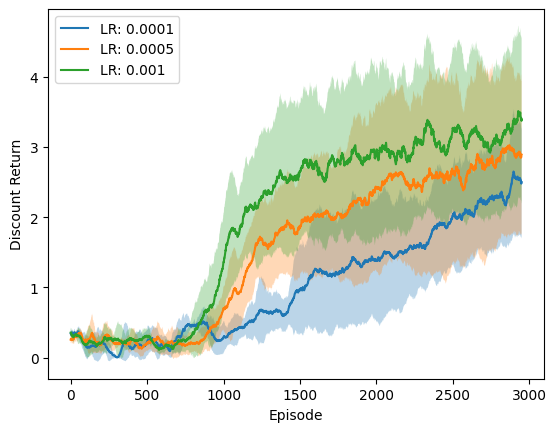

In [28]:
returns, losses, replay_models = run_prioritized_replay_dqn(
    learning_rates = [1e-4, 5e-4, 1e-3],
    num_episodes = 3000,
    num_runs = 5,
    eps = 0.05,
    warmup_steps = 1000,
    buffer_capacity = 50000,
    alpha = 0.6,
    beta_start = 0.4,
    stability_epsilon = 1e-6,
    device = "cuda"
)

all_methods_data = []
all_labels = []

for lr, seeds_data in returns.items():
    all_methods_data.append(seeds_data)
    all_labels.append(f"LR: {lr}")

# Plot using the provided utility
plot_compare_smoothed_rewards(
    train_rewards_list=all_methods_data,
    labels=all_labels,
    window=50,
    xlabel="Episode",
    ylabel="Discount Return"
)

## Helper Functions
### Saving and Loading Models
The functions now return a dictionary of model `state_dict`s. The standard PyTorch way to save and load models is using `.pth` or `.pt` files. Here is an example of how to save the best model and load it back later.

In [ ]:
# Create directories to store models and results
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Save the short run models
for lr, runs in replay_models.items():
    for run_idx, model_state_dict in enumerate(runs):
        save_path = f"models/dqn_replay_short_lr{lr}_run{run_idx}.pth"
        torch.save(model_state_dict, save_path)
        print(f"Saved short run model to {save_path}")

# Save the long run models
for lr, runs in replay_models_long.items():
    for run_idx, model_state_dict in enumerate(runs):
        save_path = f"models/dqn_replay_long_lr{lr}_run{run_idx}.pth"
        torch.save(model_state_dict, save_path)
        print(f"Saved long run model to {save_path}")

# Save the results (rewards and losses)
# Note: In the previous cells, `rewards` and `losses` were overwritten by the long run.
# So these JSON files currently contain the results from the 30,000 episode run.
rewards_json = {str(lr): runs for lr, runs in rewards.items()}
losses_json = {str(lr): runs for lr, runs in losses.items()}

with open("results/replay_rewards_long.json", "w") as f:
    json.dump(rewards_json, f)
    print("Saved long run rewards to results/replay_rewards_long.json")

with open("results/replay_losses_long.json", "w") as f:
    json.dump(losses_json, f)
    print("Saved long run losses to results/replay_losses_long.json")